### LOGISTIC REGRESSION MODELING

**Logistic Regression** models are built.      
The parameter 'class_weight="balanced"' is used to address the class imbalance.      
The features are scaled.      
The model parameters are optimized using HalvingRandomSearchCV. Scoring is based on 'recall' to try to reduce the number of False Negatives to zero.     
In line with this, the threshold is tuned to the absolute minimum threshold.     
The model performance metrics and feature importances are output separately and compared with other models in a separate notebook.
Sample predictions using the model are demonstrated.


**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel

**Load dataset**

In [2]:
# Load dataset
df = pd.read_csv('cleaned_data_bcw.csv')

In [3]:
# Examine dataset
df.head().T

,0,1,2,3,4
diagnosis,1.000000,1.000000,1.000000,1.000000,1.000000
radius_mean,17.990000,20.570000,19.690000,11.420000,20.290000
texture_mean,10.380000,17.770000,21.250000,20.380000,14.340000
perimeter_mean,122.800000,132.900000,130.000000,77.580000,135.100000
area_mean,1001.000000,1326.000000,1203.000000,386.100000,1297.000000
smoothness_mean,0.118400,0.084740,0.109600,0.142500,0.100300
compactness_mean,0.277600,0.078640,0.159900,0.283900,0.132800
concavity_mean,0.300100,0.086900,0.197400,0.241400,0.198000
concave points_mean,0.147100,0.070170,0.127900,0.105200,0.104300
symmetry_mean,0.241900,0.181200,0.206900,0.259700,0.180900


In [4]:
# Check number of rows and columns
df.shape

(569, 31)

In [5]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
# Verify data
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# Define X and y then split into train and test sets
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
# Correlation check
corr = X.corr().abs()
corr

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,0.071401,0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,0.311631,0.076437,0.261477,0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,0.253691,0.051269,0.205151,0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [9]:
# Baseline model
pipe_lr = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
])
pipe_lr.fit(X_train, y_train)



Pipeline(steps=[('scale', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

In [10]:
# Evaluate model
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158
ROC AUC: 0.9953703703703703
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [11]:
# Define parameter grid
param_grid = {
    'model__penalty': ['l1','l2'],
    'model__solver': ['saga'],
    'model__C': np.logspace(-3,3,8)
}

In [12]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe_lr, param_grid, cv=cv, scoring='recall', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': np.float64(1000.0)}
Best score: 0.9600


In [13]:
# Access the optimized pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('scale', StandardScaler()),
                ('model',
                 LogisticRegression(C=np.float64(1000.0),
                                    class_weight='balanced', max_iter=500,
                                    penalty='l1', random_state=42,
                                    solver='saga'))])

In [14]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 98.24%
The test accuracy of the model is 97.37%


In [15]:
# Generate classification
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



There at two (2) **False Negatives**. They will be reduced to zero by tuning the threshold.

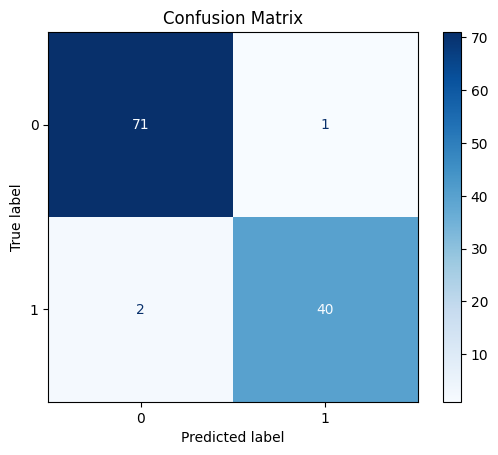

In [16]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

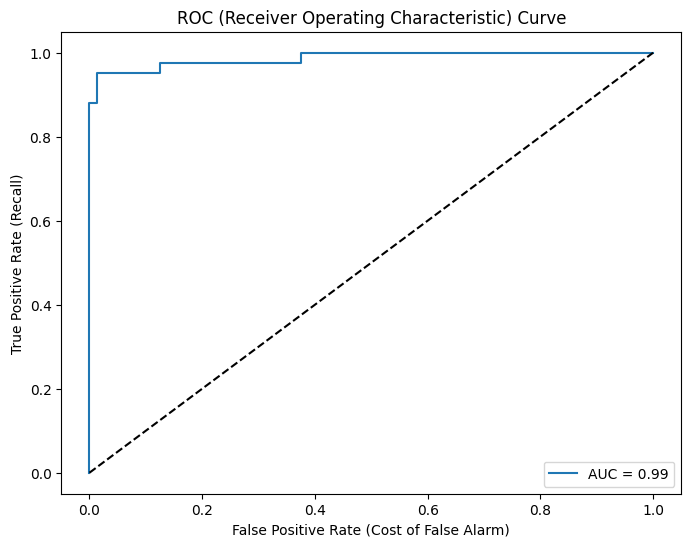

In [17]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [18]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

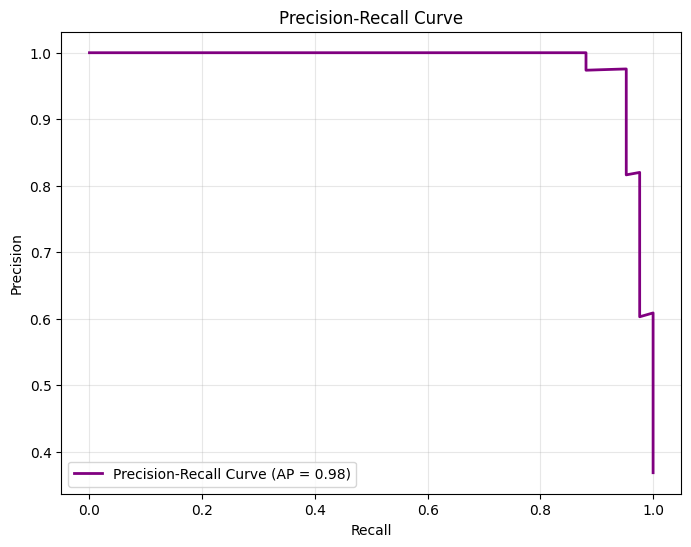

In [19]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [20]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.60, 0.05)

for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.37 | Recall=1.00
Threshold=0.05 | Precision=0.82 | Recall=0.95
Threshold=0.10 | Precision=0.85 | Recall=0.95
Threshold=0.15 | Precision=0.89 | Recall=0.95
Threshold=0.20 | Precision=0.95 | Recall=0.95
Threshold=0.25 | Precision=0.98 | Recall=0.95
Threshold=0.30 | Precision=0.98 | Recall=0.95
Threshold=0.35 | Precision=0.98 | Recall=0.95
Threshold=0.40 | Precision=0.98 | Recall=0.95
Threshold=0.45 | Precision=0.98 | Recall=0.95
Threshold=0.50 | Precision=0.98 | Recall=0.95
Threshold=0.55 | Precision=0.98 | Recall=0.95


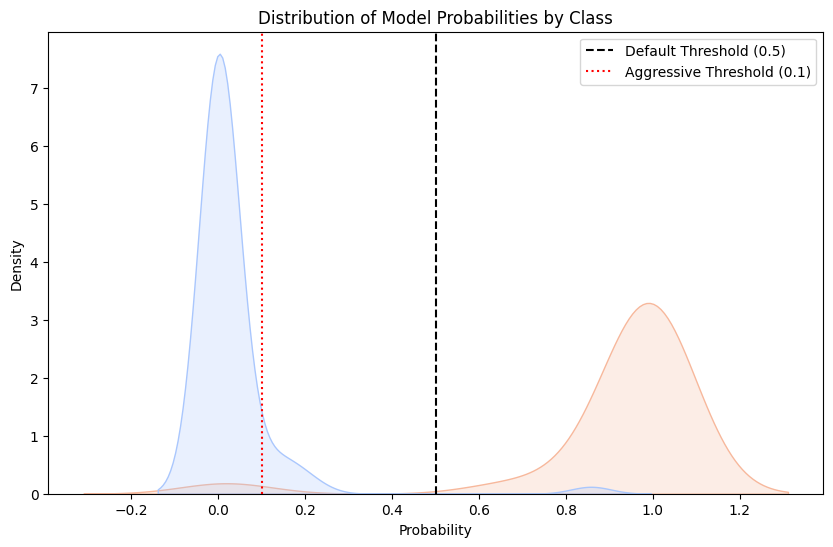

In [21]:
# Get probabilities for the positive class (Malignant)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({'Probability': y_probs, 'Actual': y_test})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x='Probability', hue='Actual', fill=True, common_norm=False, palette='coolwarm')

# Draw the current threshold (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')

# Draw a proposed aggressive threshold (e.g., 0.1)
plt.axvline(x=0.1, color='red', linestyle=':', label='Aggressive Threshold (0.1)')

plt.title('Distribution of Model Probabilities by Class')
plt.legend()
plt.show()

In [22]:
# Find the absolute minimum probability assigned to any malignant case
absolute_min_threshold = y_probs[y_test == 1].min()

print(f"Threshold for Zero False Negatives: {absolute_min_threshold:.4f}")

Threshold for Zero False Negatives: 0.0006


In [23]:
# Create final predictions
y_pred_final = (y_probs >= absolute_min_threshold).astype(int)

In [24]:
# Generate classification

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.62      0.77        72
           1       0.61      1.00      0.76        42

    accuracy                           0.76       114
   macro avg       0.80      0.81      0.76       114
weighted avg       0.86      0.76      0.76       114



The **False Negatives** are reduced to zero, however, the **False Positives** increases to twenty-seven (27).

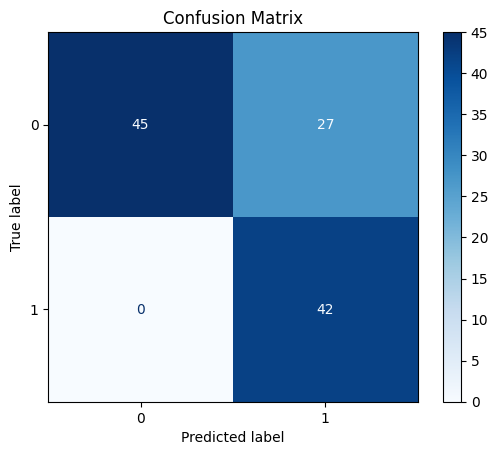

In [25]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**Feature Importance**

In [26]:
# Extract feature names
feature_names = X_train.columns

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object') 

There are 30 feature names.


In [27]:
# Extract coefficients
coefficients = best_model.named_steps['model'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [ 0.06958601  0.38790215  0.07104827  0.29446322  0.65507028 -1.52821072
  1.21520278  1.69518302 -0.67347888  0.39514964  2.84176048 -0.91835945
  1.6011192   1.87440682  0.4248397  -1.93575452 -0.4006396   1.40113833
 -0.96114335 -1.04654729  1.37609038  2.55576991  0.93914504  1.43889477
  0.11642468 -0.58126343  1.74440904  1.15605464  2.01184752  0.22674766] 

There are 30 coefficients.


In [28]:
# Construct a dataframe of coefficients
coef_df = pd.DataFrame({'feature': feature_names, 'coefs': coefficients})
coef_df = coef_df.sort_values(by='coefs', ascending=False)

print(coef_df.head(10))

                feature     coefs
10            radius_se  2.841760
21        texture_worst  2.555770
28       symmetry_worst  2.011848
13              area_se  1.874407
26      concavity_worst  1.744409
7   concave points_mean  1.695183
12         perimeter_se  1.601119
23           area_worst  1.438895
17    concave points_se  1.401138
20         radius_worst  1.376090


In [29]:
# Extract the list of selected features and coefficients for plotting
feature1 = coef_df.iloc[:9,0]
feature2 = coef_df.iloc[-8:,0]
features = pd.concat([feature1, feature2])
features = pd.DataFrame(features)
features_list = features.values.tolist()
features_list = [item for sublist in features_list for item in sublist]

coef1 = coef_df.iloc[:9,1]
coef2 = coef_df.iloc[-8:,1]
coefs = pd.concat([coef1, coef2])
coefs = pd.DataFrame(coefs)
coefs_list = coefs.values.tolist()
coefs_list = [item for sublist in coefs_list for item in sublist]

In [30]:
# Prepare to plot the important features and coefficients

plot_data = {
    'feature': features_list,
    'coefs': coefs_list
}

plot_df = pd.DataFrame(plot_data)
plot_df = plot_df.sort_values(by='coefs', ascending=True)

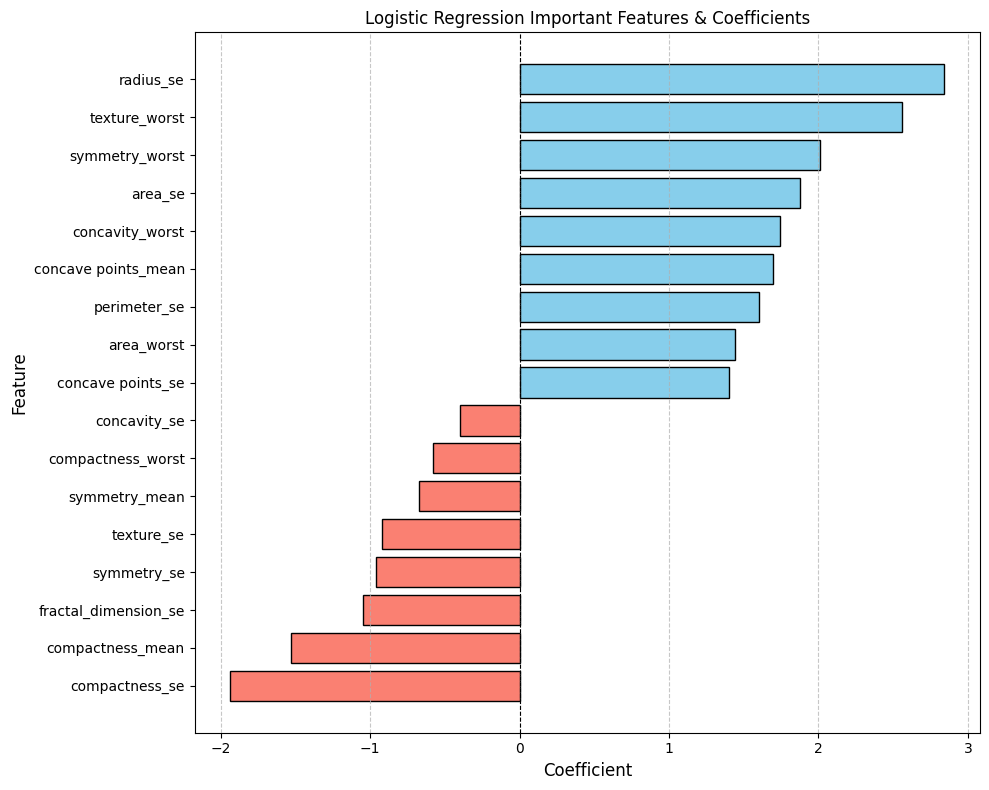

In [31]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in plot_df['coefs']]
plt.barh(plot_df['feature'], plot_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Malignancy Odds**    
**radius_se** is the number one predictor for the positive class. A unit increase of this feature raises odds of malignancy by **percent_change** assuming all other variables remain constant. This is followed by **texture_worst** and **symmetry_worst**.     
As these values go up, the probability of the positive class increases.  

On the other hand, **compactness_se** is the opposite. A unit increase in this feature decreases odds of malignancy by **percent_change** assuming all other variables remain constant. This is followed by **compactness_mean** and **fractal_dimension_se**.     
As these values go up, the probability of the positive class decreases.


In [32]:
# Calculate odds ratios and percentage change in odds
coef_df['odds_ratio'] = np.exp(coef_df['coefs'])
coef_df['percent_change'] = (coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
coef_df = coef_df.sort_values(by='coefs', ascending=False)
coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
10,radius_se,2.841760,17.145924,1614.592405
21,texture_worst,2.555770,12.881213,1188.121326
28,symmetry_worst,2.011848,7.477119,647.711875
13,area_se,1.874407,6.516952,551.695227
26,concavity_worst,1.744409,5.722519,472.251872
7,concave points_mean,1.695183,5.447643,444.764288
12,perimeter_se,1.601119,4.958579,395.857895
23,area_worst,1.438895,4.216034,321.603357
17,concave points_se,1.401138,4.059819,305.981876
20,radius_worst,1.376090,3.959392,295.939162


In [33]:
# Sort by coefs absolute values
coef_df['coefs'] = coef_df['coefs'].apply(abs)
coef_df = coef_df.sort_values(by = 'coefs', ascending = False)

coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
10,radius_se,2.841760,17.145924,1614.592405
21,texture_worst,2.555770,12.881213,1188.121326
28,symmetry_worst,2.011848,7.477119,647.711875
15,compactness_se,1.935755,0.144315,-85.568466
13,area_se,1.874407,6.516952,551.695227
26,concavity_worst,1.744409,5.722519,472.251872
7,concave points_mean,1.695183,5.447643,444.764288
12,perimeter_se,1.601119,4.958579,395.857895
5,compactness_mean,1.528211,0.216923,-78.307654
23,area_worst,1.438895,4.216034,321.603357


In [34]:
# Reset index
coef_df = coef_df.reset_index(drop=True)
coef_df.index = coef_df.index + 1
coef_df.index.name = "Rank"

coef_df.head(10)

,feature,coefs,odds_ratio,percent_change
Rank,,,,
1,radius_se,2.841760,17.145924,1614.592405
2,texture_worst,2.555770,12.881213,1188.121326
3,symmetry_worst,2.011848,7.477119,647.711875
4,compactness_se,1.935755,0.144315,-85.568466
5,area_se,1.874407,6.516952,551.695227
6,concavity_worst,1.744409,5.722519,472.251872
7,concave points_mean,1.695183,5.447643,444.764288
8,perimeter_se,1.601119,4.958579,395.857895
9,compactness_mean,1.528211,0.216923,-78.307654


**Sequential Feature Selection**     

Feature selection reduces noise and improves the interpretation of feature importance.
    
Feature selection is about removing noise, improving interpretability, improving logistic regression stability, and slightly reducing overfitting.

In [35]:
# Define the classifier
model = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [36]:
# Instantiate Sequential Feature Selector
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select="auto",
    direction="forward",
    scoring="recall",
    cv=3
)

In [37]:
# Build pipeline including sequential feature selection
pipe1 = Pipeline([
    ("scale", StandardScaler()),
    ("sfs", sfs),
    ("lgr", model)
])
pipe1.fit(X_train, y_train)
pipe1

Pipeline(steps=[('scale', StandardScaler()),
                ('sfs',
                 SequentialFeatureSelector(cv=3,
                                           estimator=LogisticRegression(class_weight='balanced',
                                                                        max_iter=500,
                                                                        random_state=42),
                                           scoring='recall')),
                ('lgr',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

In [57]:
# Define parameter grid
param_grid = {
    'lgr__penalty': ['l1','l2'],
    'lgr__solver': ['saga'],
    'lgr__C': np.logspace(-3,3,8)
}

In [58]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid1 = HalvingRandomSearchCV(pipe1, param_grid, cv=cv, scoring='recall', n_jobs=-1)
grid1.fit(X_train, y_train)

print(f'Best parameters: {grid1.best_params_}')
print(f'Best score: {grid1.best_score_:.4f}')

Best parameters: {'lgr__solver': 'saga', 'lgr__penalty': 'l1', 'lgr__C': np.float64(1000.0)}
Best score: 0.8739


In [59]:
# Get the best model from the grid search and selected features
best_model1 = grid1.best_estimator_
feature_names = X_train.columns
mask = best_model1.named_steps["sfs"].get_support()
selected_features = feature_names[mask]

print(selected_features, '\n')
print(f'There are {len(selected_features)} selected features.')

Index(['radius_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst', 'area_worst'],
      dtype='object') 

There are 15 selected features.


In [60]:
# Generate classification report
y_pred1 = best_model1.predict(X_test)

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



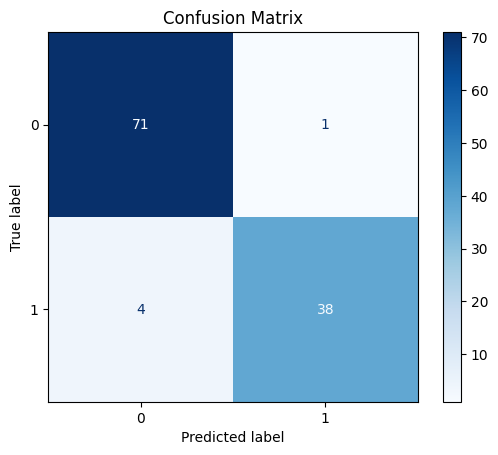

In [61]:
# Display confusion matrix
conf_matrix1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(conf_matrix1, display_labels=[0, 1])
disp1.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

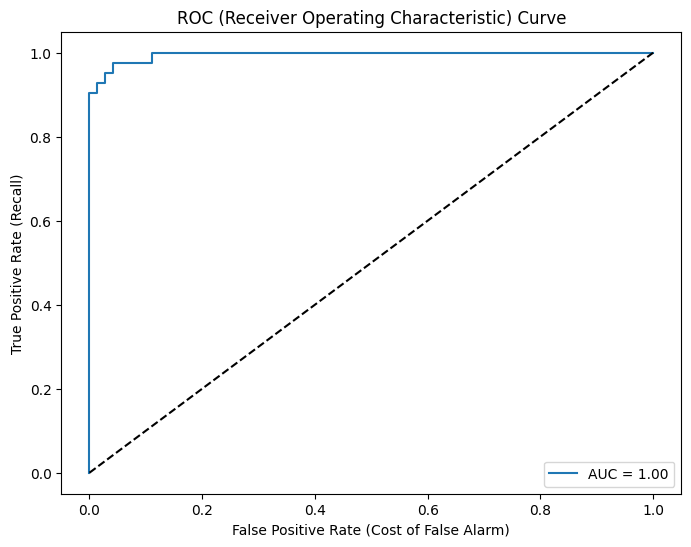

In [62]:
# Plot the ROC Curve
y_probs = best_model1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [63]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

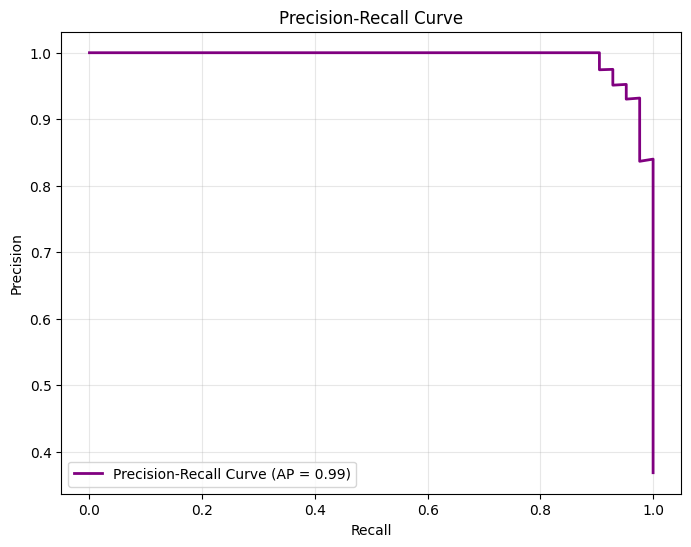

In [64]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [65]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.60, 0.05)

for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.37 | Recall=1.00
Threshold=0.05 | Precision=0.75 | Recall=1.00
Threshold=0.10 | Precision=0.84 | Recall=0.98
Threshold=0.15 | Precision=0.89 | Recall=0.98
Threshold=0.20 | Precision=0.93 | Recall=0.95
Threshold=0.25 | Precision=0.95 | Recall=0.93
Threshold=0.30 | Precision=0.95 | Recall=0.93
Threshold=0.35 | Precision=0.95 | Recall=0.93
Threshold=0.40 | Precision=0.95 | Recall=0.93
Threshold=0.45 | Precision=0.95 | Recall=0.93
Threshold=0.50 | Precision=0.97 | Recall=0.90
Threshold=0.55 | Precision=0.97 | Recall=0.90


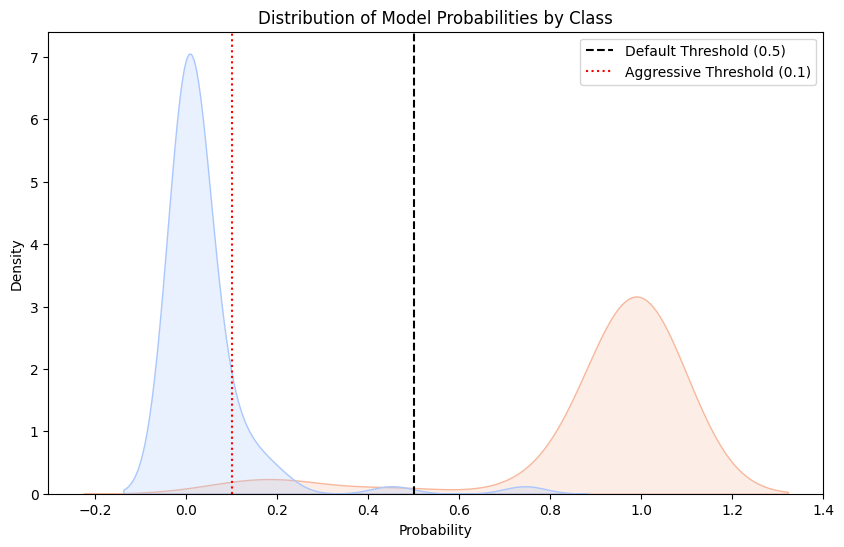

In [66]:
# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({'Probability': y_probs, 'Actual': y_test})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x='Probability', hue='Actual', fill=True, common_norm=False, palette='coolwarm')

# Draw the current threshold (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')

# Draw a proposed aggressive threshold (e.g., 0.1)
plt.axvline(x=0.1, color='red', linestyle=':', label='Aggressive Threshold (0.1)')

plt.title('Distribution of Model Probabilities by Class')
plt.legend()
plt.show()

In [67]:
# Find the absolute minimum probability assigned to any malignant case
absolute_min_threshold = y_probs[y_test == 1].min()

print(f"Threshold for Zero False Negatives: {absolute_min_threshold:.4f}")

Threshold for Zero False Negatives: 0.0961


In [68]:
# Create final predictions
y_pred_final1 = (y_probs >= absolute_min_threshold).astype(int)

In [69]:
# Generate classification report

print(classification_report(y_test, y_pred_final1))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        72
           1       0.84      1.00      0.91        42

    accuracy                           0.93       114
   macro avg       0.92      0.94      0.93       114
weighted avg       0.94      0.93      0.93       114



**False Positives** are reduced to eight (8) from twenty-seven (27) after feature reduction.

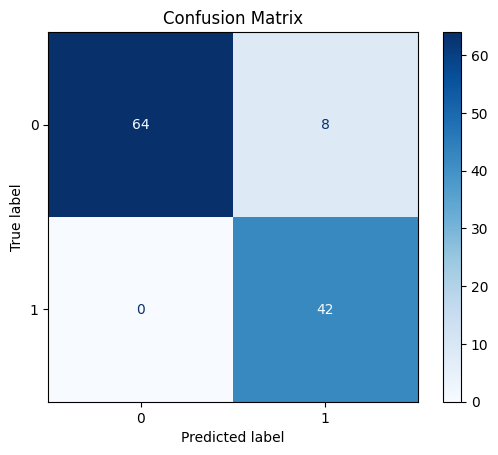

In [70]:
# Display confusion matrix
conf_matrix2 = confusion_matrix(y_test, y_pred_final1)
disp2 = ConfusionMatrixDisplay(conf_matrix2, display_labels=[0, 1])
disp2.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [71]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix2[0][1]
fn = conf_matrix2[1][0]
tp = conf_matrix2[1][1]
tn = conf_matrix2[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn_L5: {tn}')

 fp: 8 
 fn: 0 
 tp: 42 
 tn_L5: 64


In [72]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.93
Precision: 0.84
Recall: 1.00
---------------


In [73]:
# Build a dataframe summarizing the model properties
lgr_metrics_df = pd.DataFrame({
    'Model': ['Logistic_Regression'],
    'ROC_AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'False_Negatives': [fn],
    'False_Positives': [fp],
})
lgr_metrics_df

,Model,ROC_AUC,Accuracy,Precision,Recall,False_Negatives,False_Positives
0,Logistic_Regression,0.995,0.929825,0.84,1.0,0,8


**Feature Importance**

In [74]:
# Extract feature names
feature_names = X_train.columns

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object') 

There are 30 feature names.


In [76]:
# Extract selected features
selector = best_model1.named_steps["sfs"]
mask = selector.get_support()
selected_features = feature_names[mask]

print(f'The selected features are: \n \n {selected_features} \n')
print(f'There are {len(selected_features)} selected features.')

The selected features are: 
 
 Index(['radius_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst', 'area_worst'],
      dtype='object') 

There are 15 selected features.


In [77]:
# Extract coefficients
coefficients = best_model1.named_steps['lgr'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [ 0.21747738  1.09049037 -1.49707121  2.09878107  1.95107633  0.81983533
  0.64558708 -0.30532089  0.391288   -0.91877186  0.45395075 -1.11329293
  3.26707695  2.29111376  3.26271179] 

There are 15 coefficients.


In [78]:
# Construct a dataframe of coefficients
coef_df = pd.DataFrame({'feature': selected_features, 'coefs': coefficients})
coef_df = coef_df.sort_values(by='coefs', ascending=False)

print(coef_df.head(10))

                   feature     coefs
12            radius_worst  3.267077
14              area_worst  3.262712
13           texture_worst  2.291114
3           concavity_mean  2.098781
4      concave points_mean  1.951076
1          smoothness_mean  1.090490
5            symmetry_mean  0.819835
6   fractal_dimension_mean  0.645587
10            concavity_se  0.453951
8            smoothness_se  0.391288


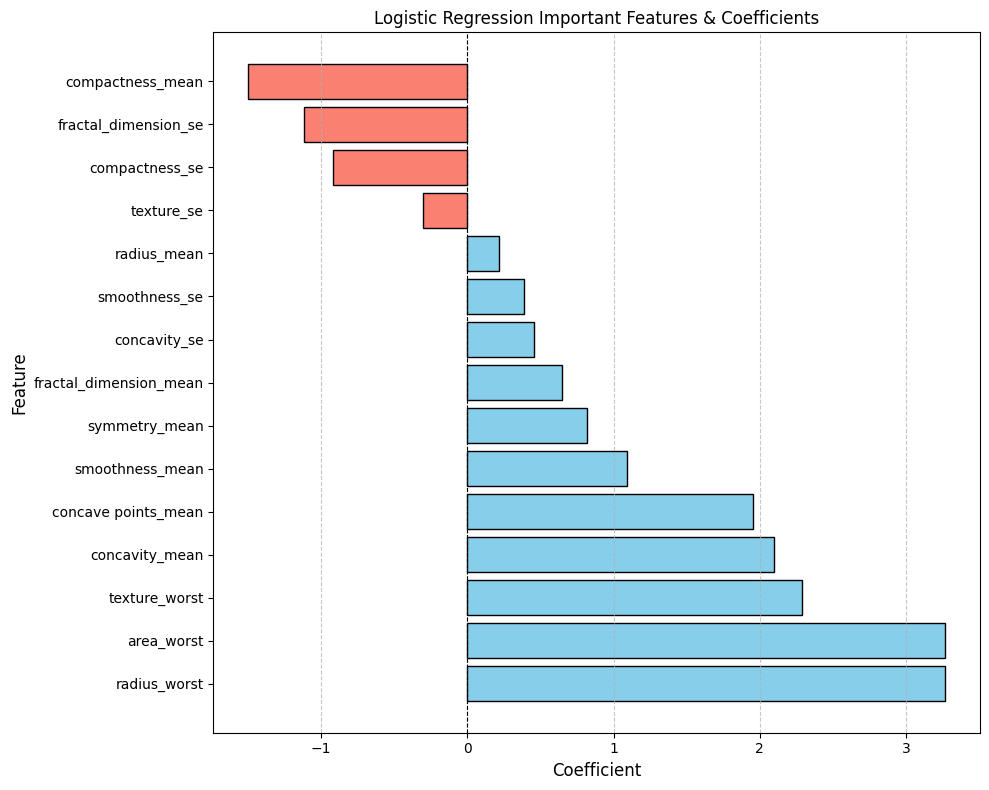

In [79]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in coef_df['coefs']]
plt.barh(coef_df['feature'], coef_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Malignancy Odds**    
**radius_worst** is the number one predictor for the positive class. A unit increase of this feature raises odds of malignancy by **percent_change** assuming all other variables remain constant. This is followed by **area_worst** and **texture_worst**.     
As these values go up, the probability of the positive class increases.  

On the other hand, **compactness_mean** is the opposite. A unit increase in this feature decreases odds of malignancy by **percent_change** assuming all other variables remain constant. This is followed by **fractal_dimension_se** and **ompactness_se**.     
As these values go up, the probability of the positive class decreases.


In [80]:
# Calculate odds ratios and percentage change in odds
coef_df['odds_ratio'] = np.exp(coef_df['coefs'])
coef_df['percent_change'] = (coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
coef_df = coef_df.sort_values(by='coefs', ascending=False)
coef_df.head(15)

,feature,coefs,odds_ratio,percent_change
12,radius_worst,3.267077,26.234542,2523.454241
14,area_worst,3.262712,26.120274,2512.027387
13,texture_worst,2.291114,9.885942,888.594215
3,concavity_mean,2.098781,8.156222,715.622200
4,concave points_mean,1.951076,7.036257,603.625682
1,smoothness_mean,1.090490,2.975733,197.573293
5,symmetry_mean,0.819835,2.270126,127.012599
6,fractal_dimension_mean,0.645587,1.907106,90.710632
10,concavity_se,0.453951,1.574520,57.452045
8,smoothness_se,0.391288,1.478884,47.888437


In [81]:
# Sort by coefs absolute values
coef_df['coefs'] = coef_df['coefs'].apply(abs)
coef_df = coef_df.sort_values(by = 'coefs', ascending = False)

coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
12,radius_worst,3.267077,26.234542,2523.454241
14,area_worst,3.262712,26.120274,2512.027387
13,texture_worst,2.291114,9.885942,888.594215
3,concavity_mean,2.098781,8.156222,715.622200
4,concave points_mean,1.951076,7.036257,603.625682
2,compactness_mean,1.497071,0.223785,-77.621538
11,fractal_dimension_se,1.113293,0.328476,-67.152447
1,smoothness_mean,1.090490,2.975733,197.573293
9,compactness_se,0.918772,0.399009,-60.099122
5,symmetry_mean,0.819835,2.270126,127.012599


In [82]:
# Reset index
coef_df = coef_df.reset_index(drop=True)
coef_df.index = coef_df.index + 1
coef_df.index.name = "Rank"

coef_df.head(15)

,feature,coefs,odds_ratio,percent_change
Rank,,,,
1,radius_worst,3.267077,26.234542,2523.454241
2,area_worst,3.262712,26.120274,2512.027387
3,texture_worst,2.291114,9.885942,888.594215
4,concavity_mean,2.098781,8.156222,715.622200
5,concave points_mean,1.951076,7.036257,603.625682
6,compactness_mean,1.497071,0.223785,-77.621538
7,fractal_dimension_se,1.113293,0.328476,-67.152447
8,smoothness_mean,1.090490,2.975733,197.573293
9,compactness_se,0.918772,0.399009,-60.099122


In [83]:
# Output the Logistic Regression model performance metrics
lgr_metrics_df.to_csv("lgr_metrics.csv", index=False)

In [84]:
# Output the features importance
lgr_features_df = coef_df.iloc[:, :2]
lgr_features_df.to_csv("lgr_features.csv", index=False)

**Sample Predictions**

In [85]:
# List indices of malignant cases
malignant_idx = y_test[y_test == 1].index

print(malignant_idx)

Index([250,  99,  39, 479, 280,  73, 218,  34,  86, 100,  64, 468,  70, 118,
       451,  22, 385,   7, 196, 219,  83, 207, 563,  14, 321, 198,   5, 162,
         4,  94, 277, 177, 433, 533, 190, 487, 393, 329, 282, 503, 205,  75],
      dtype='int64')


**Sample 1**

In [86]:
# Obtain a sample from the test data
df_test1 = X_test.loc[39]

print(df_test1, '\n')
print(f'Actual diagnosis is {y_test.loc[39]}')

radius_mean                 13.480000
texture_mean                20.820000
perimeter_mean              88.400000
area_mean                  559.200000
smoothness_mean              0.101600
compactness_mean             0.125500
concavity_mean               0.106300
concave points_mean          0.054390
symmetry_mean                0.172000
fractal_dimension_mean       0.064190
radius_se                    0.213000
texture_se                   0.591400
perimeter_se                 1.545000
area_se                     18.520000
smoothness_se                0.005367
compactness_se               0.022390
concavity_se                 0.030490
concave points_se            0.012620
symmetry_se                  0.013770
fractal_dimension_se         0.003187
radius_worst                15.530000
texture_worst               26.020000
perimeter_worst            107.300000
area_worst                 740.400000
smoothness_worst             0.161000
compactness_worst            0.422500
concavity_wo

In [87]:
# Transfer the data to a dictionary
sample1 = {    "radius_mean": 13.480000,    "texture_mean": 20.820000,    "perimeter_mean": 88.400000,    "area_mean": 559.200000,    "smoothness_mean": 0.101600,    "compactness_mean": 0.125500,    "concavity_mean": 0.106300,    "concave points_mean": 0.054390,    "symmetry_mean": 0.172000,    "fractal_dimension_mean": 0.064190,    "radius_se": 0.213000,    "texture_se": 0.591400,    "perimeter_se": 1.545000,    "area_se": 18.520000,    "smoothness_se": 0.005367,    "compactness_se": 0.022390,    "concavity_se": 0.030490,    "concave points_se": 0.012620,    "symmetry_se": 0.013770,    "fractal_dimension_se": 0.003187,    "radius_worst": 15.530000,    "texture_worst": 26.020000,    "perimeter_worst": 107.300000,    "area_worst": 740.400000,    "smoothness_worst": 0.161000,    "compactness_worst": 0.422500,    "concavity_worst": 0.503000,    "concave points_worst": 0.225800,    "symmetry_worst": 0.280700,    "fractal_dimension_worst": 0.107100}

In [88]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability1 = best_model.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability1:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 0.92


In [89]:
# Obtain a sample from the test data
df_test2 = X_test.loc[198]

print(df_test2, '\n')
print(f'Actual diagnosis is {y_test.loc[198]}')

radius_mean                  19.180000
texture_mean                 22.490000
perimeter_mean              127.500000
area_mean                  1148.000000
smoothness_mean               0.085230
compactness_mean              0.142800
concavity_mean                0.111400
concave points_mean           0.067720
symmetry_mean                 0.176700
fractal_dimension_mean        0.055290
radius_se                     0.435700
texture_se                    1.073000
perimeter_se                  3.833000
area_se                      54.220000
smoothness_se                 0.005524
compactness_se                0.036980
concavity_se                  0.027060
concave points_se             0.012210
symmetry_se                   0.014150
fractal_dimension_se          0.003397
radius_worst                 23.360000
texture_worst                32.060000
perimeter_worst             166.400000
area_worst                 1688.000000
smoothness_worst              0.132200
compactness_worst        

In [90]:
# Transfer the data to a dictionary
sample2 = {
    "radius_mean": 19.180000,
    "texture_mean": 22.490000,
    "perimeter_mean": 127.500000,
    "area_mean": 1148.000000,
    "smoothness_mean": 0.085230,
    "compactness_mean": 0.142800,
    "concavity_mean": 0.111400,
    "concave points_mean": 0.067720,
    "symmetry_mean": 0.176700,
    "fractal_dimension_mean": 0.055290,
    "radius_se": 0.435700,
    "texture_se": 1.073000,
    "perimeter_se": 3.833000,
    "area_se": 54.220000,
    "smoothness_se": 0.005524,
    "compactness_se": 0.036980,
    "concavity_se": 0.027060,
    "concave points_se": 0.012210,
    "symmetry_se": 0.014150,
    "fractal_dimension_se": 0.003397,
    "radius_worst": 23.360000,
    "texture_worst": 32.060000,
    "perimeter_worst": 166.400000,
    "area_worst": 1688.000000,
    "smoothness_worst": 0.132200,
    "compactness_worst": 0.560100,
    "concavity_worst": 0.386500,
    "concave points_worst": 0.170800,
    "symmetry_worst": 0.319300,
    "fractal_dimension_worst": 0.092210
}

In [91]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability2 = best_model.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability2:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 1.00


In [92]:
# Obtain a sample from the test data
df_test3 = X_test.loc[250]

print(df_test3, '\n')
print(f'Actual diagnosis is {y_test.loc[250]}')

radius_mean                  20.940000
texture_mean                 23.560000
perimeter_mean              138.900000
area_mean                  1364.000000
smoothness_mean               0.100700
compactness_mean              0.160600
concavity_mean                0.271200
concave points_mean           0.131000
symmetry_mean                 0.220500
fractal_dimension_mean        0.058980
radius_se                     1.004000
texture_se                    0.820800
perimeter_se                  6.372000
area_se                     137.900000
smoothness_se                 0.005283
compactness_se                0.039080
concavity_se                  0.095180
concave points_se             0.018640
symmetry_se                   0.024010
fractal_dimension_se          0.005002
radius_worst                 25.580000
texture_worst                27.000000
perimeter_worst             165.300000
area_worst                 2010.000000
smoothness_worst              0.121100
compactness_worst        

In [93]:
# Transfer the data to a dictionary
sample3 = {
    "radius_mean": 20.940000,
    "texture_mean": 23.560000,
    "perimeter_mean": 138.900000,
    "area_mean": 1364.000000,
    "smoothness_mean": 0.100700,
    "compactness_mean": 0.160600,
    "concavity_mean": 0.271200,
    "concave points_mean": 0.131000,
    "symmetry_mean": 0.220500,
    "fractal_dimension_mean": 0.058980,
    "radius_se": 1.004000,
    "texture_se": 0.820800,
    "perimeter_se": 6.372000,
    "area_se": 137.900000,
    "smoothness_se": 0.005283,
    "compactness_se": 0.039080,
    "concavity_se": 0.095180,
    "concave points_se": 0.018640,
    "symmetry_se": 0.024010,
    "fractal_dimension_se": 0.005002,
    "radius_worst": 25.580000,
    "texture_worst": 27.000000,
    "perimeter_worst": 165.300000,
    "area_worst": 2010.000000,
    "smoothness_worst": 0.121100,
    "compactness_worst": 0.317200,
    "concavity_worst": 0.699100,
    "concave points_worst": 0.210500,
    "symmetry_worst": 0.312600,
    "fractal_dimension_worst": 0.078490
}

In [94]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability3 = best_model.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability3:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 1.00
